In [63]:
import os 
import numpy as np
import scipy.io as sio
from scipy.signal import butter,filtfilt

#the bandpass filter
#4Hz-38Hz
def apply_bandpass(data, lowcut= 4.0, highcut = 38.0, fs = 250.0, order = 4):
    nyq = 0.5*fs
    low = lowcut/nyq
    high = highcut/nyq
    b, a = butter(order, [low, high], btype = 'band')

    return filtfilt(b,a,data,axis = 0)

def process_and_save_subject(mat_file_path, subject_id):
    print(f"\nProcessing subject {subject_id}")
    mat_data = sio.loadmat(mat_file_path)
    all_runs = mat_data['data'][0]

    SFREQ = 250
    Action_start = int(0.5*SFREQ)
    Action_end = int(2.5*SFREQ)
    Baseline_start = int(-0.2*SFREQ)
    baseline_end = 0

    all_clean_epochs = []
    all_clean_labels = []

    for run_idx, run in enumerate(all_runs):
        X = run['X'].item()
        y = run['y'].item()
        trial = run['trial'].item()

        if len(y) == 0:
            continue #no actual data present because non-motor stuff

        eeg_only = X[:, :22]
        filtered_eeg = apply_bandpass(eeg_only)

        for i in range(len(trial)):
            start_idx = trial[i][0]
            epoch = filtered_eeg[start_idx + Action_start : start_idx + Action_end , :]

            baseline = filtered_eeg[start_idx + Baseline_start : start_idx + baseline_end , :]

            b_mean = np.mean(baseline, axis = 0)
            b_std = np.std(baseline, axis = 0)
            normalized_epoch = (epoch-b_mean) / (b_std + 1e-6)
            
            if np.max(np.abs(normalized_epoch)) < 100:
                all_clean_epochs.append(normalized_epoch)
                all_clean_labels.append(y[i][0] - 1)

    final_X = np.array(all_clean_epochs).transpose(0, 2, 1)
    final_y = np.array(all_clean_labels)

    print(f"Extracted {len(final_y)} clean trials.")
    print(f"Final X Tensor Shape: {final_X.shape}")
    
    # --- 3. Save to Disk ---
    save_dir = "processed_data"
    os.makedirs(save_dir, exist_ok=True)
    
    np.save(os.path.join(save_dir, f"sub_{subject_id}_X.npy"), final_X)
    np.save(os.path.join(save_dir, f"sub_{subject_id}_y.npy"), final_y)
    print(f"Saved to {save_dir}/sub_{subject_id}_X.npy")

# Run it for Subject 1
process_and_save_subject('TrainingTesting-Data/A09T.mat', '09')


Processing subject 09
Extracted 288 clean trials.
Final X Tensor Shape: (288, 22, 500)
Saved to processed_data/sub_09_X.npy


In [64]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

class BCIDataset(Dataset):
    def __init__(self, x_path, y_path):
        self.X = np.load(x_path)
        self.Y = np.load(y_path)

        self.X = torch.tensor(self.X, dtype = torch.float32)
        self.Y = torch.tensor(self.Y, dtype = torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx): 
        return self.X[idx], self.Y[idx]

dataset = BCIDataset('processed_data/sub_09_X.npy', 'processed_data/sub_09_y.npy')
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)  

data_batch, label_batch = next(iter(dataloader))
print(f"Batch X Shape: {data_batch.shape} -> (Batch_Size, Channels, Time)")
print(f"Batch y Shape: {label_batch.shape} -> (Batch_Size)")

Batch X Shape: torch.Size([32, 22, 500]) -> (Batch_Size, Channels, Time)
Batch y Shape: torch.Size([32]) -> (Batch_Size)


In [65]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

class BCIDataset(Dataset):
    def __init__(self, x_path, y_path):
        self.X = np.load(x_path)
        self.Y = np.load(y_path)

        self.X = torch.tensor(self.X, dtype = torch.float32)
        self.Y = torch.tensor(self.Y, dtype = torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx): 
        return self.X[idx], self.Y[idx]

dataset = BCIDataset('processed_data/sub_09_X.npy', 'processed_data/sub_09_y.npy')
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)  

data_batch, label_batch = next(iter(dataloader))
print(f"Batch X Shape: {data_batch.shape} -> (Batch_Size, Channels, Time)")
print(f"Batch y Shape: {label_batch.shape} -> (Batch_Size)")

Batch X Shape: torch.Size([32, 22, 500]) -> (Batch_Size, Channels, Time)
Batch y Shape: torch.Size([32]) -> (Batch_Size)


In [66]:
import torch.nn as nn

class SpatialGatedCAE(nn.Module):
    def __init__(self, in_channels = 22, virtual_channels=8, latent_dim = 16):
        super(SpatialGatedCAE, self).__init__()
        self.spatial_gate = nn.Conv1d(in_channels, virtual_channels, kernel_size=1)

        self.temporal_blur = nn.MaxPool1d(kernel_size = 4)
        flattened_size = virtual_channels * 125
    
        self.encoder = nn.Sequential(
            nn.Linear(flattened_size, 128),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(0.2), #changes the weights being trained to prevent overfitting 
            nn.Linear(128, latent_dim), #linear transformation of data
            nn.Sigmoid() #normaliser
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(128, flattened_size)
        )
    
    def forward(self, x):
        mixed_x = self.spatial_gate(x) #the bottleneck part
        blurred_x = self.temporal_blur(mixed_x) #blurs the time to handle power changes and reduce errors
        flattened = blurred_x.view(blurred_x.size(0),-1)
        latent_weights = self.encoder(flattened)
        reconstructed = self.decoder(latent_weights)

        return reconstructed, latent_weights, flattened
    
model = SpatialGatedCAE()
reconstructed, latent, original_flat = model(data_batch)

print(f"\nModel Output Check:")
print(f"Latent Weights Shape: {latent.shape} -> (Batch_Size, Latent_Dim)")
print(f"Reconstructed Shape: {reconstructed.shape} -> Should match flattened size")



Model Output Check:
Latent Weights Shape: torch.Size([32, 16]) -> (Batch_Size, Latent_Dim)
Reconstructed Shape: torch.Size([32, 1000]) -> Should match flattened size


In [67]:
#Loss calculator
def compute_contractive_loss(reconstructed, original, latent_weights, model, lambda_reg):
    mse_loss = nn.MSELoss()(reconstructed, original)

    W = model.encoder[3].weight
    dh = latent_weights * (1-latent_weights)

   # (Sensitivity of weights) * (State of the activation gate)
    jacobian_penalty = torch.sum(torch.pow(dh,2) * torch.sum(torch.pow(W,2),dim=1), dim=1) 

    #lambda_reg: How aggressively we punish noise
    
    return mse_loss + (lambda_reg*jacobian_penalty.mean())

In [68]:
#training loop
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "CPU")
model = SpatialGatedCAE().to(device)

optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

EPOCHS = 50
print(f"training starting on device {device}")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for batch_X, _ in dataloader: #getting batches of training data from the dataloader class
        batch_X = batch_X.to(device) #using the actual device specified 
        optimizer.zero_grad() #refreshing the gradients for the current run of the trials

        reconstructed, latent, flattened_original = model(batch_X)
        loss = compute_contractive_loss(reconstructed, flattened_original, latent, model, 1e-4)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        avg_loss = running_loss / len(dataloader)
        print(f"Epoch [{epoch + 1}/{EPOCHS}] | Contractive Loss: {avg_loss:.6f}")

print("\n Training Complete")

# 4. Save the "Archetype" to the hard drive
save_path = "sub_09_cae_weights.pth"
torch.save(model.state_dict(), save_path)
print(f" Archetype successfully saved to {save_path}")



training starting on device cuda
Epoch [10/50] | Contractive Loss: 0.034074
Epoch [20/50] | Contractive Loss: 0.015291
Epoch [30/50] | Contractive Loss: 0.010564
Epoch [40/50] | Contractive Loss: 0.007962
Epoch [50/50] | Contractive Loss: 0.006219

 Training Complete
 Archetype successfully saved to sub_09_cae_weights.pth


--- VISUALIZING THE RECONSTRUCTION ---


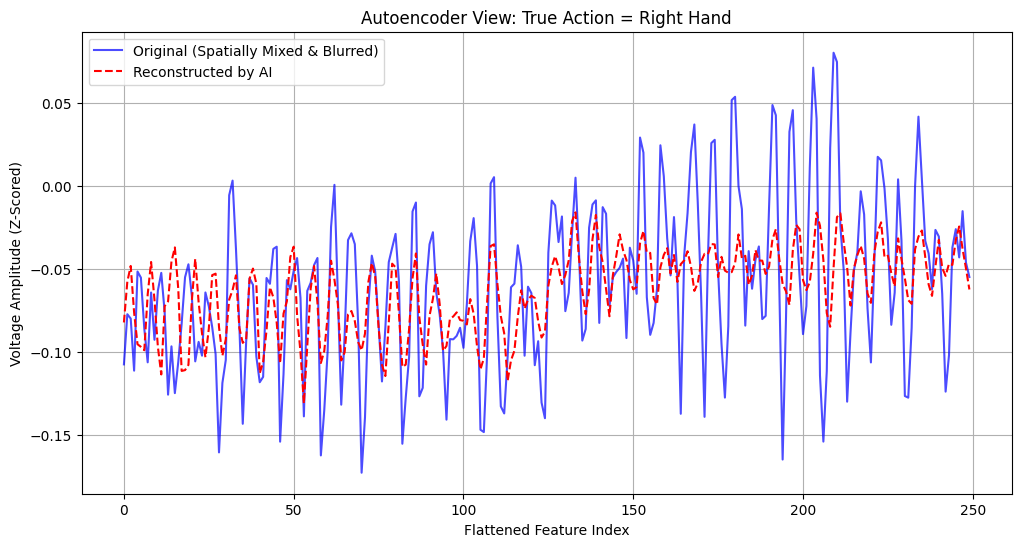

Look at the plot. The red line likely follows the blue line perfectly.
The Autoencoder did its job perfectly... but the 'intent' was lost.


In [72]:
import matplotlib.pyplot as plt

print("--- VISUALIZING THE RECONSTRUCTION ---")
# 1. Grab a single batch of data
model.eval()
with torch.no_grad():
    sample_X, sample_y = next(iter(dataloader))
    sample_X = sample_X.to(device)
    
    # Run it through the model
    reconstructed, latent, flattened_original = model(sample_X)

# 2. Move the first trial of the batch to the CPU for plotting
# We take trial index 0
orig_wave = flattened_original[0].cpu().numpy()
recon_wave = reconstructed[0].cpu().numpy()
true_label = sample_y[0].item()

target_names = ["Left Hand", "Right Hand", "Both Feet", "Tongue"]
action_name = target_names[true_label]

# 3. Plotting
plt.figure(figsize=(12, 6))
plt.title(f"Autoencoder View: True Action = {action_name}")

# Plot a slice of the 1000-dimension array (e.g., the first 250 steps)
slice_end = 250
plt.plot(orig_wave[:slice_end], label="Original (Spatially Mixed & Blurred)", color='blue', alpha=0.7)
plt.plot(recon_wave[:slice_end], label="Reconstructed by AI", color='red', linestyle='dashed')

plt.xlabel("Flattened Feature Index")
plt.ylabel("Voltage Amplitude (Z-Scored)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Look at the plot. The red line likely follows the blue line perfectly.")
print(f"The Autoencoder did its job perfectly... but the 'intent' was lost.")

In [70]:
import torch 
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

print("latent features extraction")
model.eval()

all_latent_features = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in dataloader:
        batch_X = batch_X.to(device)

        _,latent,_ = model(batch_X)

        all_latent_features.append(latent.cpu().numpy())
        all_labels.append(batch_y.cpu().numpy())

X_features = np.vstack(all_latent_features)
y_true = np.concatenate(all_labels)

print(f"Extracted Features Shape: {X_features.shape} -> (Trials, 16 Priority Weights)")

print("\n--- TRAINING THE RANDOM FOREST ---")
#80-20 split for training,testing
X_train, X_test, y_train, y_test = train_test_split(X_features, y_true, test_size=0.2, random_state=42)

# Initialize the RF. We use 'balanced' class weights just in case some trials were dropped earlier
rf = RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42, class_weight='balanced') 
#max_depth 10 means only 10 if else gated questions, class_weight = balanced, penalizes the model for lazy guessing
rf.fit(X_train, y_train)

latent features extraction
Extracted Features Shape: (288, 16) -> (Trials, 16 Priority Weights)

--- TRAINING THE RANDOM FOREST ---


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [71]:
print("\n--- FINAL EVALUATION ---")
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Final Edge-Pipeline Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
# Kaggle Labels: 0=Left, 1=Right, 2=Foot, 3=Tongue
target_names = ["Left Hand", "Right Hand", "Both Feet", "Tongue"]
print(classification_report(y_test, y_pred, target_names=target_names))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


--- FINAL EVALUATION ---
Final Edge-Pipeline Accuracy: 25.86%

Classification Report:
              precision    recall  f1-score   support

   Left Hand       0.47      0.37      0.41        19
  Right Hand       0.15      0.15      0.15        13
   Both Feet       0.24      0.36      0.29        11
      Tongue       0.15      0.13      0.14        15

    accuracy                           0.26        58
   macro avg       0.25      0.25      0.25        58
weighted avg       0.27      0.26      0.26        58

Confusion Matrix:
[[7 8 3 1]
 [3 2 3 5]
 [1 1 4 5]
 [4 2 7 2]]
